In [44]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cmocean as cmo


ds = xr.open_dataset("hydro_FlocOn.nc", decode_times=False)
print(ds)

ds2 = xr.open_dataset("hydro_FlocOn.nc", decode_times=False)

nt = len(ds.time) - 1


<xarray.Dataset> Size: 12MB
Dimensions:  (time: 600, Ds: 40, z: 50)
Coordinates:
  * time     (time) float32 2kB 0.0 50.0 110.0 ... 3.581e+04 3.587e+04 3.593e+04
  * Ds       (Ds) float32 160B 1e-05 1.137e-05 1.293e-05 ... 0.001319 0.0015
  * z        (z) float32 200B 9.9 9.7 9.5 9.3 9.1 8.9 ... 0.9 0.7 0.5 0.3 0.1
Data variables:
    ssc      (time, Ds, z) float64 10MB ...
    mass     (Ds) float64 320B ...
    U        (time, z) float64 240kB ...
    Kq       (time, z) float64 240kB ...
    Nu       (time, z) float64 240kB ...
    C        (time, z) float64 240kB ...
    Kz       (time, z) float64 240kB ...
    L        (time, z) float64 240kB ...
    Q2       (time, z) float64 240kB ...
    Q2L      (time, z) float64 240kB ...
    N_BV2    (time, z) float64 240kB ...
Attributes:
    title:    testing


<>:31: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:31: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1807995/3675103879.py:31: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))


(-10.0, 0.0)

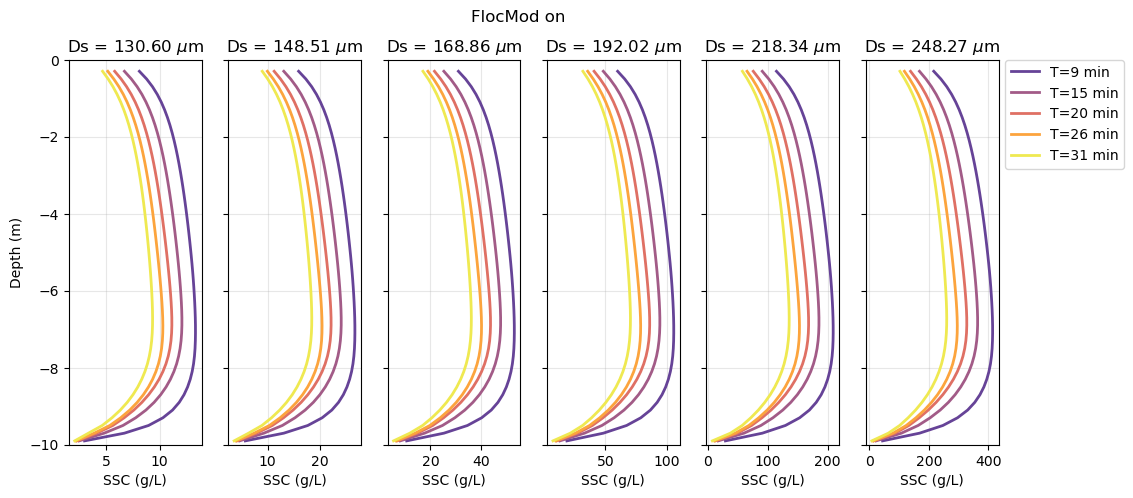

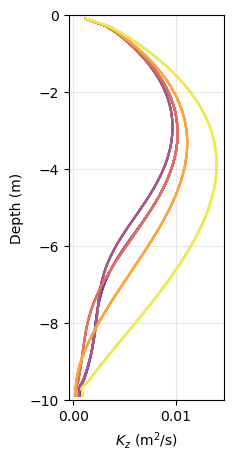

In [45]:
fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(12, 5), sharex=False, sharey=True)
axs = axs.flatten()
plt.suptitle("FlocMod on")


# fig2, axs2 = plt.subplots(nrows=1, ncols=6, figsize=(12, 5), sharex=False, sharey=True)
# plt.suptitle("FlocMod off")

fig3 = plt.figure(figsize=(2, 5))
ax3 = plt.gca() 

ST = 20 
stop = nt//3
for t in range(nt//10, stop, stop//6):
    for i, d in enumerate(range(ST,ST+6,1)):
        # i = i*4
        color = cmo.cm.thermal(t/stop) 
        # var = ds.Kz.isel(time=t)
        var = ds.Kq.isel(time=t)
        ax3.plot(var, -ds.z, color=color, label="T=%d min" % (t*10/60))


        var = ds.ssc.isel(time=t).isel(Ds=d)
        mass = ds.mass.isel(Ds=d)
        # print(var.values)
        h= axs[i].plot(var[0:-1]*mass, -ds.z[0:-1], color=color, label="T=%d min" % (t*10/60), linewidth=2)
        axs[i].grid(alpha=0.3)
        axs[i].set_xlabel("SSC (g/L)")
        # axs2[i].grid(alpha=0.3)

        axs[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))
        axs[i].set_ylim(-10, 0)
        # axs2[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))


axs[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
# axs2[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
axs[0].set_ylabel("Depth (m)")

ax3.set_xlabel("$K_z$ (m$^2$/s)")
ax3.grid(alpha=0.3)
ax3.set_ylabel("Depth (m)")
ax3.set_ylim(-10, 0)

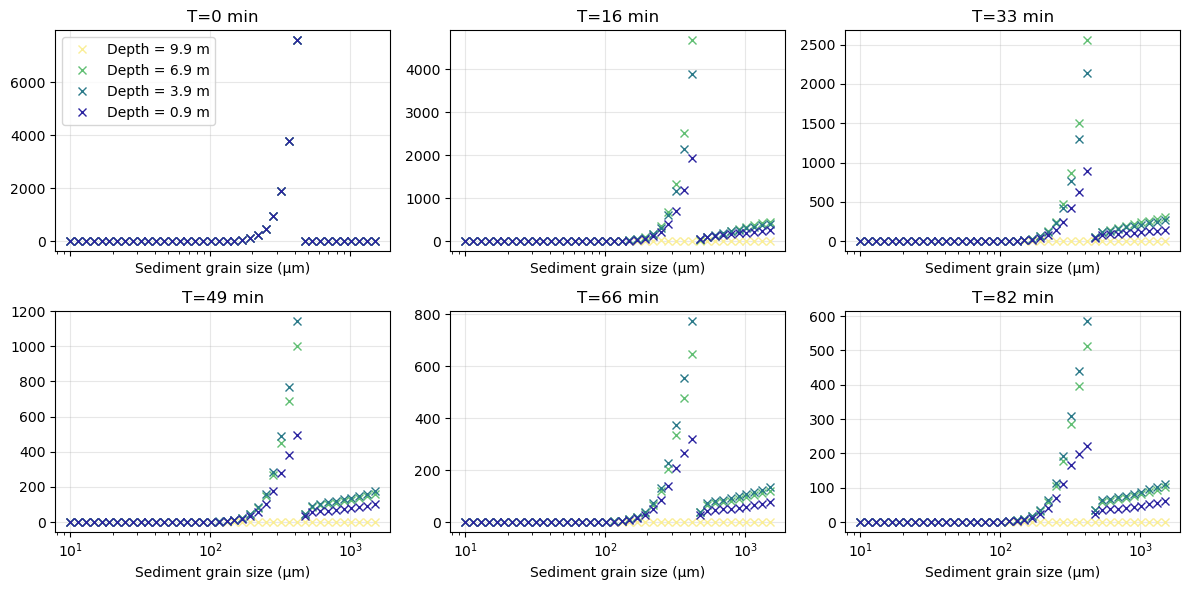

In [46]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=True, sharey=False)
axs = axs.flatten()

z = ds.z.values
mass = ds.mass.values
for i,t in enumerate(range(0, nt, nt//6)):
    # var = ds.Kz.isel(time=12)
    if i>5:
        continue
    for dep in range(0, 50, 15):
        var = ds.ssc.isel(z=dep).isel(time=t) * mass
        axs[i].plot(ds.Ds.values*1e6, var, 'x', color=cmo.cm.haline(z[dep]/10), label="Depth = %2.1f m" % z[dep]) #,color=cmo.cm.thermal(t/nt))
       

    axs[i].set_xscale('log')
    axs[i].grid(alpha=0.3)
    axs[i].set_title("T=%d min" % (t*10/60))
    # axs[i].set_yscale('log')

    axs[i].set_xlabel("Sediment grain size (µm)")
    # axs[i].set_ylabel("10$^6$ particles/m$^3$")
axs[0].legend()
plt.tight_layout()

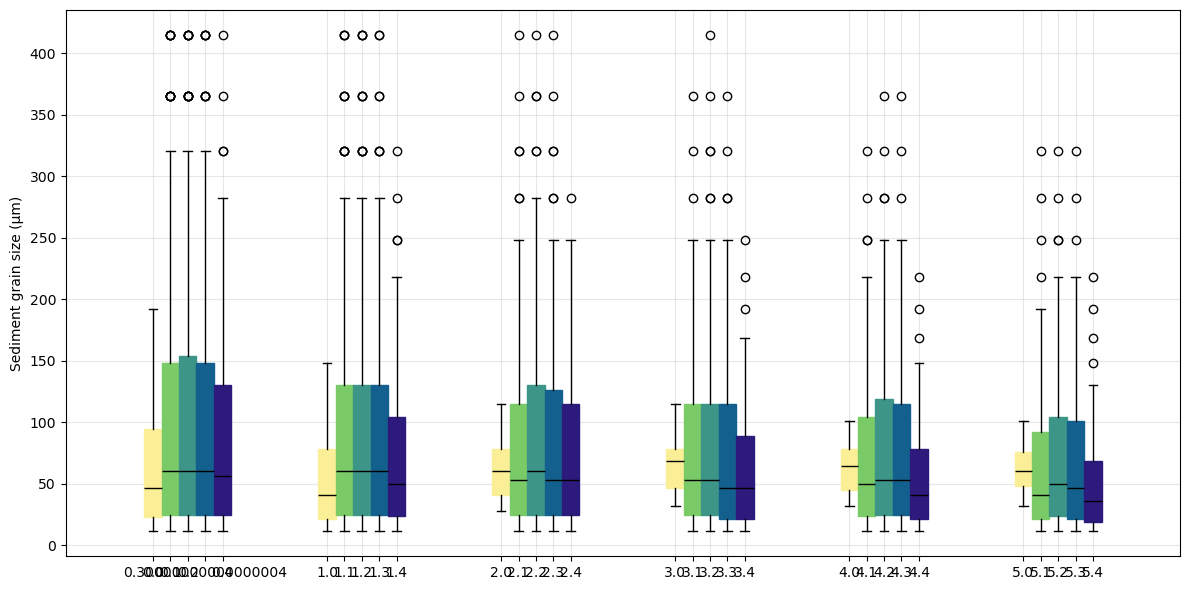

In [47]:
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()

z = ds.z.values
mass = ds.mass.values
nt = len(ds.time) - 1
D = ds.Ds.values*1e6
for i, dep in enumerate(range(0, len(z), len(z)//4)):
    for j,t in enumerate(range(100, nt, nt//6)):
        # print(j, t)
        # var = ds.Kz.isel(time=12)
        var = ds.ssc.isel(z=dep).isel(time=t) /1e6 #* mass

        expanded_D = np.repeat(D, var)
        ax.boxplot(expanded_D, positions=[j+0.1*i], widths=0.1, patch_artist=True, boxprops=dict(facecolor=cmo.cm.haline(z[dep]/10), color=cmo.cm.haline(z[dep]/10)), medianprops=dict(color='black')) #,color=cmo.cm.thermal(t/nt))
        
        # (ds.Ds.values*1e6, var, 'x', color=cmo.cm.haline(z[dep]/10), label="Depth = %2.1f m" % z[dep]) #,color=cmo.cm.thermal(t/nt))
       

ax.grid(alpha=0.3)
# ax.set_xticks(range(0, nt, nt//6))
# ax.set_xticklabels(["T=%d min" % (t*10/60) for
    # axs[i].set_xscale('log')
    # axs[i].grid(alpha=0.3)
    # axs[i].set_title("T=%d min" % (t*10/60))
    # # axs[i].set_yscale('log')

ax.set_ylabel("Sediment grain size (µm)")
    # axs[i].set_ylabel("10$^6$ particles/m$^3$")
axs[0].legend()
plt.tight_layout()

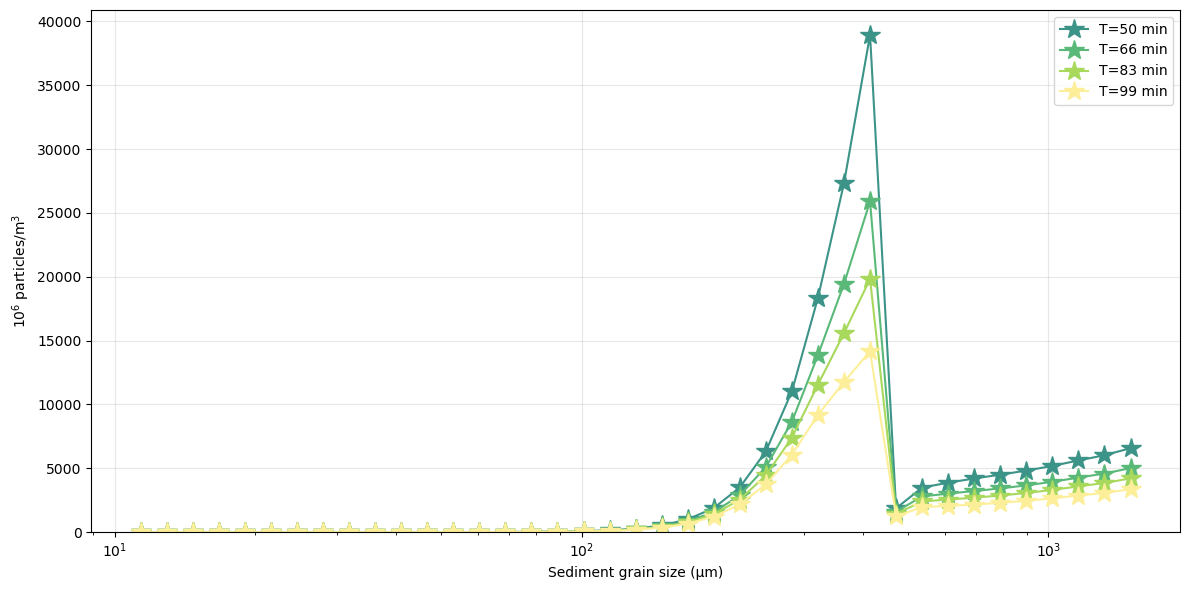

In [48]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(12, 6), sharex=True, sharey=True)

z = ds.z.values
for i,t in enumerate(range(300, nt, nt//6)):
    # var = ds.Kz.isel(time=12)

    label="T=%d min" % (t*10/60)
    # print(i, t, time)
    
    var = ds.ssc.isel(time=t).sum(dim='z')
    var[var<2] = np.nan
    axs.plot(ds.Ds.values*1e6, var*mass, '-*', color=cmo.cm.haline(t/nt), markersize=15, label=label) #,color=cmo.cm.thermal(t/nt))
# axs[i].plot(ds.ssc.isel(time=400).isel(Ds=i), ds.z)
    # print(var)
# print(var.values) 
    axs.set_xscale('log')
    axs.grid(alpha=0.3)
    # axs.set_yscale('log')

    axs.set_xlabel("Sediment grain size (µm)")
    axs.set_ylabel("10$^6$ particles/m$^3$")
axs.legend()
axs.set_ylim(0,)
plt.tight_layout()

(0.3055555522441864, 99.47222137451172)

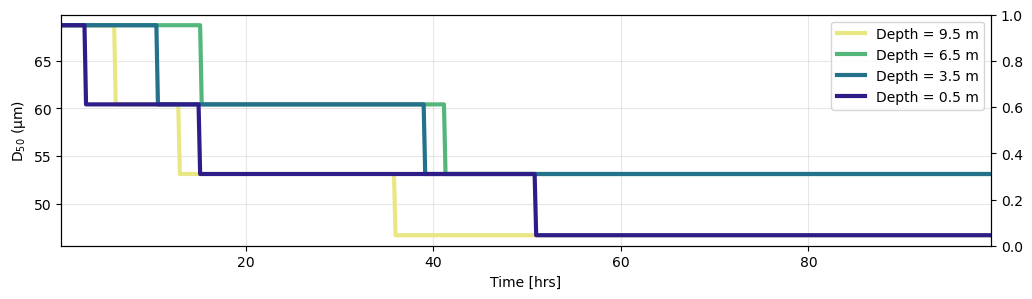

In [49]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 3), sharex=True, sharey=True)
ax2 = ax.twinx()

z = ds.z.values

for dep in range(2, 50, 15):
    hours = ds.time.values / 360
    var = ds.ssc.isel(z=dep) # .isel(time=t)
    # print(ds.Ds.values.shape, var.values.shape)
    # broadcast Ds to match var shape
    Ds = np.broadcast_to(ds.Ds.values, var.values.shape)
    weights = var.values + 1e-3
    mean_d = np.percentile(Ds, axis=1, q=50, weights=weights, method="inverted_cdf")
    ax.plot(hours, mean_d*1e6, color=cmo.cm.haline(z[dep]/10), linewidth=3, label="Depth = %2.1f m" % z[dep]) #,color=cmo.cm.thermal(t/nt))
    # kz = ds.Kq.mean(dim="z")
    # ax2.plot(hours, kz, linewidth=3, alpha = 0.5)

# ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend()
# ax.set_xlim(0, 5)
ax.set_xlabel("Time [hrs]")
ax.set_ylabel("D$_{50}$ (µm)")
ax.set_xlim(hours[2], hours[-3])
# axs[i].set_ylabel("10$^6$ particles/m$^3$")
# axs[0].legend()
# plt.tight_layout()

<xarray.Dataset> Size: 12MB
Dimensions:  (time: 600, Ds: 40, z: 50)
Coordinates:
  * time     (time) float32 2kB 0.0 50.0 110.0 ... 3.581e+04 3.587e+04 3.593e+04
  * Ds       (Ds) float32 160B 1e-05 1.137e-05 1.293e-05 ... 0.001319 0.0015
  * z        (z) float32 200B 9.9 9.7 9.5 9.3 9.1 8.9 ... 0.9 0.7 0.5 0.3 0.1
Data variables:
    ssc      (time, Ds, z) float64 10MB 1e+07 1e+07 1e+07 ... 45.34 35.83 40.5
    mass     (Ds) float64 320B 1.388e-12 2.777e-12 5.557e-12 ... 0.3907 0.7819
    U        (time, z) float64 240kB ...
    Kq       (time, z) float64 240kB ...
    Nu       (time, z) float64 240kB 0.000197 0.000197 ... 0.003881 0.001952
    C        (time, z) float64 240kB ...
    Kz       (time, z) float64 240kB ...
    L        (time, z) float64 240kB ...
    Q2       (time, z) float64 240kB 1e-06 1e-06 1e-06 ... 0.002123 0.001192
    Q2L      (time, z) float64 240kB ...
    N_BV2    (time, z) float64 240kB ...
Attributes:
    title:    testing
[0.         0.01388889 0.03055556 

Text(0.5, 1.0, 'U')

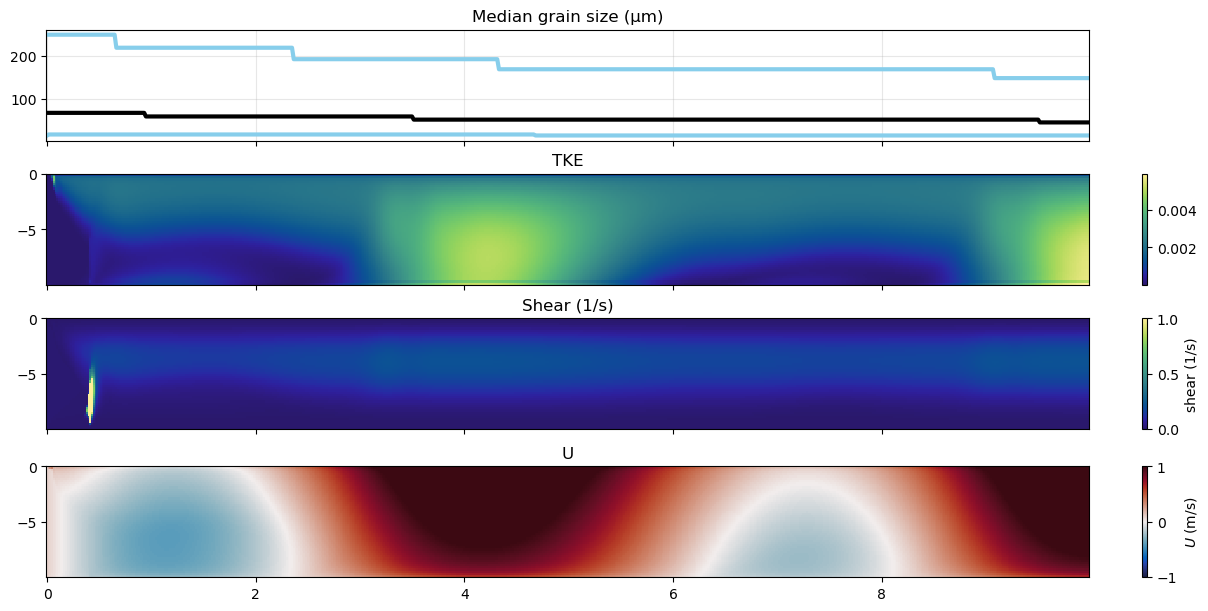

In [56]:
print(ds)

fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12, 6), sharex=True, sharey=False, constrained_layout=True)

z = -ds.z.values
time = ds.time.values /3600 # * 60/3600
mass = ds.mass.values
Ds = ds.Ds.values*1e6
print(time[0:5])

ind= 15
ssc = ds.ssc #.isel(Ds=ind)  #* mass[ind]
# print(max(ssc.values.flatten()))
# h = axs[0].pcolormesh(time, z, ssc.T, cmap=cmo.cm.rain) #, color=cmo.cm.haline)
# h = plt.colorbar(h, label="Sediment (mg/L)")

weights = ssc.mean(dim='z') # * mass 

Ds_broadcasted = np.broadcast_to(Ds[:, np.newaxis], weights.T.shape)
mean_d = np.percentile(Ds_broadcasted, axis=0, q=50, weights=weights.T, method="inverted_cdf")
axs[0].plot(time, mean_d, color='black', linewidth=3) #,color=cmo.cm.thermal(t/nt))
# axs[0].set_yscale('log')
mean_d = np.percentile(Ds_broadcasted, axis=0, q=16, weights=weights.T, method="inverted_cdf")
axs[0].plot(time, mean_d, color='skyblue', linewidth=3) #,color=cmo.cm.thermal(t/nt))
mean_d = np.percentile(Ds_broadcasted, axis=0, q=84, weights=weights.T, method="inverted_cdf")
axs[0].plot(time, mean_d, color='skyblue', linewidth=3) #,color=cmo.cm.thermal(t/nt))
axs[0].grid(alpha=0.3)
axs[0].set_title("Median grain size (µm)")
# assert(False)
# kappa = ds.Nu #isel(Ds=ind)  * mass[ind]
# print(max(kappa.values.flatten()))
# h = axs[1].pcolormesh(time, z, np.log(kappa.T), cmap=cmo.cm.haline) #, color=cmo.cm.haline)
# h = plt.colorbar(h, label=r"$\kappa$ (m$^2$/s)")

kappa = ds.Q2 #isel(Ds=ind)  * mass[ind]
h = axs[1].pcolormesh(time, z, kappa.T, cmap=cmo.cm.haline) #, color=cmo.cm.haline)
h = plt.colorbar(h) #, label=r"$\kappa$ (m$^2$/s)")
axs[1].set_title("TKE")


# kappa = ds.Nu #isel(Ds=ind)  * mass[ind]
shear =np.sqrt(ds.Kq)/ (ds.Q2 / ds.Q2L)**2  # np.sqrt(ds.Q2) # *100
print(max(shear.values.flatten()))
h = axs[2].pcolormesh(time, z, shear.T, cmap=cmo.cm.haline,vmin=0, vmax=1) #, color=cmo.cm.haline)
axs[2].set_title("Shear (1/s)")
h = plt.colorbar(h, label=r"shear (1/s)")


U = ds.U #isel(Ds=ind)  * mass[ind]
h = axs[3].pcolormesh(time, z, U.T, cmap=cmo.cm.balance, vmin=-1, vmax=1) #, color=cmo.cm.haline)
h = plt.colorbar(h, label=r"$U$ (m/s)")
axs[3].set_title("U")
# kappa = ds.Kz #isel(Ds=ind)  * mass[ind]
# print(max(kappa.values.flatten()))
# h = axs[1].pcolormesh(time, z, np.log(kappa.T), cmap=cmo.cm.haline) #, color=cmo.cm.haline)
# h = plt.colorbar(h, label=r"$\kappa$ (m$^2$/s)")